# 🦵⚡ RSNA Knee Abnormality Detection — Plane-Aware 2.5D MIL GPU Baseline

## Strategic summary

**Competition objective.** Predict 12 clinically important knee MRI abnormalities and maximize **macro ROC AUC** across targets.

**Baseline hypothesis.** A full 3D model is unnecessarily expensive for the first anchor. A stronger cost/performance baseline is to preserve MRI plane diversity while reducing each selected series to a compact **2.5D triplet** (three adjacent slices). A shared CNN encodes sagittal, coronal, and axial views; a learned study-level attention layer pools them into one 12-label prediction.

### Why this baseline

| Design choice | Decision | Rationale |
|---|---|---|
| Unit of prediction | MRI study | Matches `StudyInstanceUID` submission rows |
| Input | Up to 3 orthogonal MRI series | Different targets are best exposed in different planes |
| Per-series representation | 3 adjacent central slices → pseudo-RGB | Cheap 2.5D context without 3D memory cost |
| Encoder | ResNet-18 | Fast, reproducible GPU anchor; easy to replace later |
| Fusion | Learned attention across views | Lets the model weight planes per study |
| Objective | Masked weighted BCE | Handles class imbalance and preserves any missing labels |
| Validation | Leakage-safe patient grouping when available | Prevents same-patient train/validation contamination |
| Runtime target | Single GPU, comfortably below 9 hours | Designed for Kaggle code-competition constraints |

### What this notebook deliberately does **not** claim

This is an **image-only anchor**, not the final multimodal solution. It intentionally avoids report-text fusion until the MRI validation backbone is measured cleanly. The winning development path is expected to test: pretrained medical/SSL encoders, target-specific plane experts, richer slice sampling/localization, radiology-report fusion, fold ensembles, and teacher-student distillation.

### Acceptance criterion for the next challenger

Keep a change only if it improves **leakage-safe OOF macro AUC**, is stable across targets/folds, and remains compatible with the 9-hour inference/training budget.

## 1. Setup and reproducibility

The notebook auto-discovers the competition directory by inspecting `sample_submission.csv`, so it is resilient to Kaggle input mount naming. All randomness is seeded. Mixed precision is enabled on CUDA.

In [1]:
import os
import gc
import math
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupShuffleSplit, StratifiedShuffleSplit

import pydicom
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

SEED = 2026
IMG_SIZE = 192
BATCH_SIZE = 8
EPOCHS = 4
LR = 3e-4
WEIGHT_DECAY = 1e-4
VAL_FRACTION = 0.15
NUM_WORKERS = min(4, os.cpu_count() or 2)
N_VIEWS = 3
PLANE_ORDER = ('sagittal', 'coronal', 'axial')
MAX_TRAIN_STUDIES = None   # set an integer only for debugging
MAX_TEST_STUDIES = None
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_ENABLED = DEVICE.type == 'cuda'


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything()
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 2. Discover competition files

The discovery logic identifies the official target columns directly from `sample_submission.csv` rather than hard-coding assumptions about CSV filenames.

In [2]:
SUBMISSION_ID = 'StudyInstanceUID'


def discover_competition_root(base='/kaggle/input'):
    base = Path(base)
    candidates = []
    for p in base.rglob('sample_submission.csv'):
        try:
            tmp = pd.read_csv(p, nrows=3)
            if SUBMISSION_ID in tmp.columns and len(tmp.columns) >= 13:
                candidates.append(p.parent)
        except Exception:
            pass
    if not candidates:
        raise FileNotFoundError(
            'Could not auto-discover the RSNA Knee competition directory. '
            'Attach the competition data and ensure sample_submission.csv is present.'
        )
    # Prefer a root whose path mentions both rsna and knee.
    candidates = sorted(candidates, key=lambda p: ('rsna' not in str(p).lower() or 'knee' not in str(p).lower(), len(str(p))))
    return candidates[0]

COMP_ROOT = discover_competition_root()
SAMPLE_PATH = COMP_ROOT / 'sample_submission.csv'
sample_submission = pd.read_csv(SAMPLE_PATH)
TARGETS = [c for c in sample_submission.columns if c != SUBMISSION_ID]


def find_csv_with_columns(root, required, forbidden=None):
    required = set(required)
    forbidden = set(forbidden or [])
    hits = []
    for p in Path(root).rglob('*.csv'):
        if p.name == 'sample_submission.csv':
            continue
        try:
            cols = set(pd.read_csv(p, nrows=2).columns)
            if required.issubset(cols) and not forbidden.intersection(cols):
                hits.append(p)
        except Exception:
            pass
    return sorted(hits, key=lambda p: len(str(p)))

train_hits = find_csv_with_columns(COMP_ROOT, [SUBMISSION_ID] + TARGETS)
if not train_hits:
    raise FileNotFoundError('No training CSV containing StudyInstanceUID and all 12 targets was found.')
TRAIN_PATH = train_hits[0]
train_df = pd.read_csv(TRAIN_PATH)

test_hits = find_csv_with_columns(COMP_ROOT, [SUBMISSION_ID], forbidden=TARGETS)
TEST_PATH = test_hits[0] if test_hits else None
if TEST_PATH is not None:
    test_df = pd.read_csv(TEST_PATH)
else:
    test_df = sample_submission[[SUBMISSION_ID]].copy()

print('Competition root:', COMP_ROOT)
print('Train CSV:', TRAIN_PATH.name, train_df.shape)
print('Test CSV:', TEST_PATH.name if TEST_PATH else '(using sample submission IDs)', test_df.shape)
print('Targets:', TARGETS)
display(train_df.head(3))

Competition root: /kaggle/input/competitions/rsna-knee-abnormality-detection
Train CSV: train.csv (4407, 14)
Test CSV: test.csv (3, 1)
Targets: ['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Early EDA — target signal and imbalance

These plots are intentionally placed before modeling. They expose target prevalence, multi-label burden, and label dependence — all of which influence loss weighting, validation stability, and future target-specific expert design.

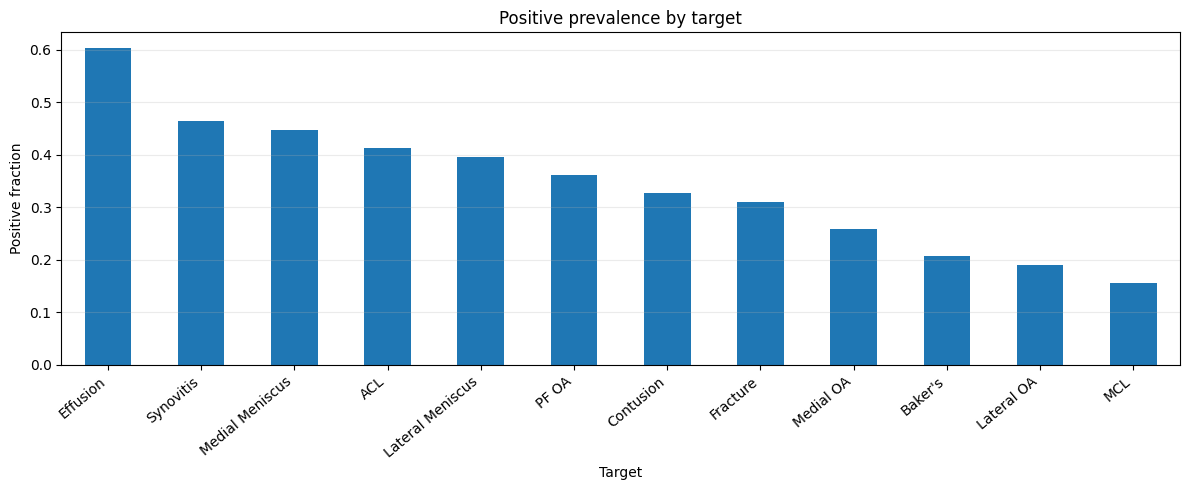

,positive_rate,missing_rate
Effusion,0.6034,0.9868
Synovitis,0.4655,0.9868
Medial Meniscus,0.4483,0.9868
ACL,0.4138,0.9868
Lateral Meniscus,0.3966,0.9868
PF OA,0.3621,0.9868
Contusion,0.3276,0.9868
Fracture,0.3103,0.9868
Medial OA,0.2586,0.9868
Baker's,0.2069,0.9868


In [3]:
label_matrix = train_df[TARGETS].apply(pd.to_numeric, errors='coerce')
prevalence = label_matrix.mean().sort_values(ascending=False)
missing = label_matrix.isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
prevalence.plot(kind='bar', ax=ax)
ax.set_title('Positive prevalence by target')
ax.set_ylabel('Positive fraction')
ax.set_xlabel('Target')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

summary = pd.DataFrame({'positive_rate': prevalence, 'missing_rate': missing.reindex(prevalence.index)})
display(summary.round(4))

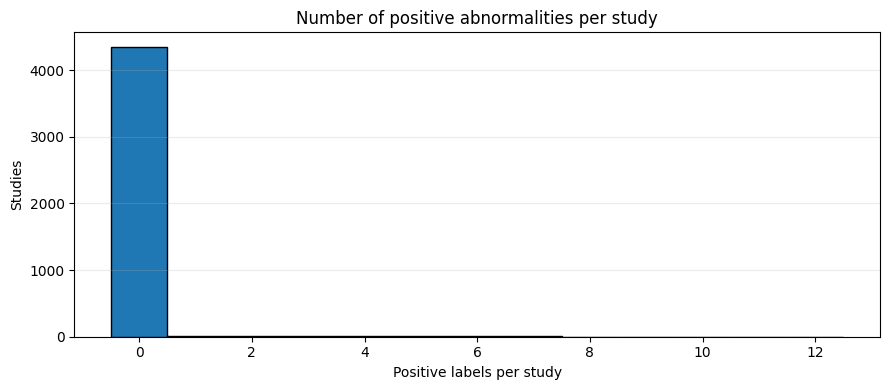

count    4407.000
mean        0.054
std         0.535
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         9.000
dtype: float64


In [4]:
cardinality = label_matrix.fillna(0).sum(axis=1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(cardinality, bins=np.arange(-0.5, len(TARGETS)+1.5, 1), edgecolor='black')
ax.set_title('Number of positive abnormalities per study')
ax.set_xlabel('Positive labels per study')
ax.set_ylabel('Studies')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

print(cardinality.describe().round(3))

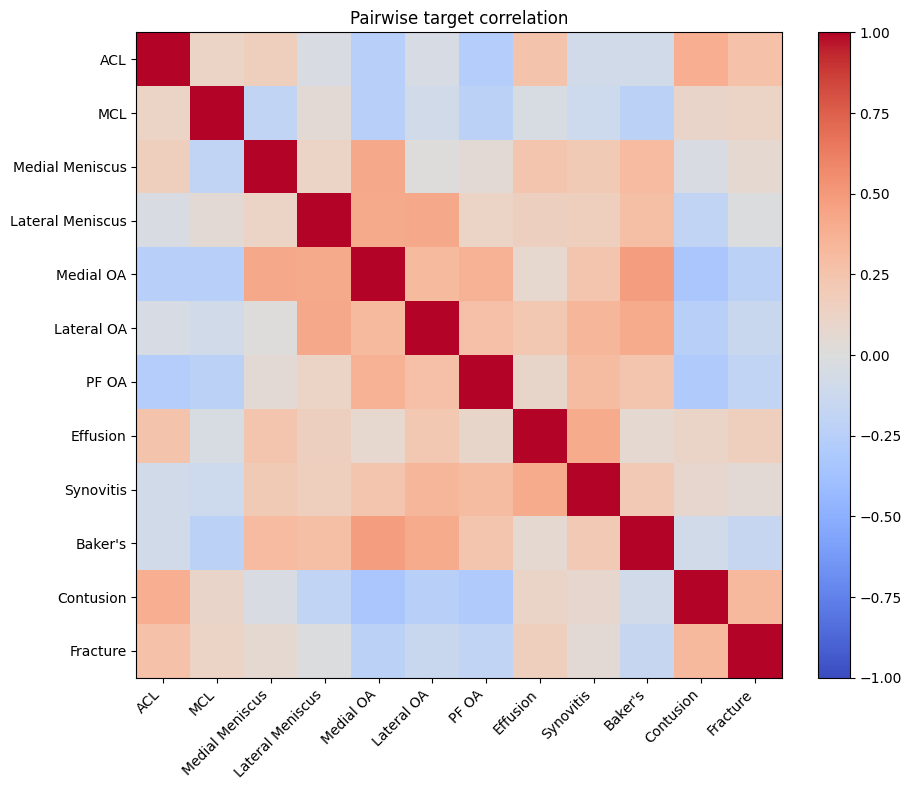

In [5]:
co = label_matrix.corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(co.values, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(TARGETS)))
ax.set_yticks(range(len(TARGETS)))
ax.set_xticklabels(TARGETS, rotation=45, ha='right')
ax.set_yticklabels(TARGETS)
ax.set_title('Pairwise target correlation')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 4. Leakage-safe split

If patient-level identity exists, validation is grouped by patient. Otherwise, the study UID itself is used and a multi-label pattern proxy is used for stratification. The prevalence drift plot below is a required sanity check: a single holdout is only useful if rare targets are not accidentally removed from validation.

Seeded random holdout fallback
Train / val: 3745 662


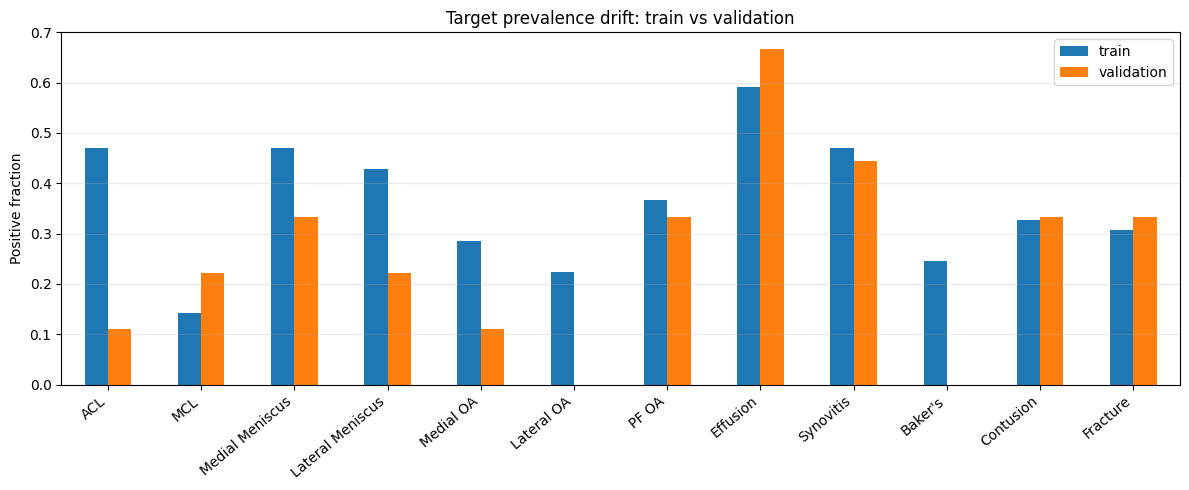

In [6]:
PATIENT_CANDIDATES = ['PatientID', 'patient_id', 'PatientId', 'patientId', 'SubjectID', 'subject_id']
patient_col = next((c for c in PATIENT_CANDIDATES if c in train_df.columns), None)

indices = np.arange(len(train_df))
if patient_col is not None and train_df[patient_col].nunique(dropna=True) < len(train_df):
    groups = train_df[patient_col].fillna(train_df[SUBMISSION_ID]).astype(str)
    splitter = GroupShuffleSplit(n_splits=1, test_size=VAL_FRACTION, random_state=SEED)
    train_idx, val_idx = next(splitter.split(indices, groups=groups))
    split_method = f'GroupShuffleSplit by {patient_col}'
else:
    y_bin = label_matrix.fillna(0).astype(int)
    pattern = y_bin.astype(str).agg(''.join, axis=1)
    counts = pattern.value_counts()
    strat_key = pattern.where(pattern.map(counts) >= 2, 'k' + y_bin.sum(axis=1).astype(str))
    try:
        splitter = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRACTION, random_state=SEED)
        train_idx, val_idx = next(splitter.split(indices, strat_key))
        split_method = 'StratifiedShuffleSplit on compressed multi-label pattern'
    except Exception:
        rng = np.random.default_rng(SEED)
        shuffled = rng.permutation(indices)
        cut = int(len(shuffled) * (1 - VAL_FRACTION))
        train_idx, val_idx = shuffled[:cut], shuffled[cut:]
        split_method = 'Seeded random holdout fallback'

if MAX_TRAIN_STUDIES is not None:
    train_idx = train_idx[:MAX_TRAIN_STUDIES]

print(split_method)
print('Train / val:', len(train_idx), len(val_idx))

prev_train = label_matrix.iloc[train_idx].mean()
prev_val = label_matrix.iloc[val_idx].mean()
plot_df = pd.DataFrame({'train': prev_train, 'validation': prev_val})
plot_df.plot(kind='bar', figsize=(12, 5))
plt.title('Target prevalence drift: train vs validation')
plt.ylabel('Positive fraction')
plt.xticks(rotation=40, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Build a study → series DICOM index

We scan the mounted competition input once and map files to study UIDs from the CSVs. Each series is assigned an anatomical plane from `ImageOrientationPatient` when available. This avoids repeatedly walking the filesystem during training.

In [7]:
all_study_uids = set(train_df[SUBMISSION_ID].astype(str)) | set(test_df[SUBMISSION_ID].astype(str))


def infer_uid_from_path(path_parts, uid_set):
    for part in reversed(path_parts):
        if part in uid_set:
            return part
    return None


def classify_plane_from_iop(iop):
    try:
        iop = np.asarray([float(x) for x in iop], dtype=float)
        row, col = iop[:3], iop[3:]
        normal = np.abs(np.cross(row, col))
        axis = int(np.argmax(normal))
        return ('sagittal', 'coronal', 'axial')[axis]
    except Exception:
        return 'unknown'


def _read_series_header(path):
    return pydicom.dcmread(path, stop_before_pixels=True, force=True)


def sort_series_files(files):
    """Sort a DICOM series spatially when possible; InstanceNumber is the fallback."""
    records = []
    plane = 'unknown'
    description = ''
    normal = None

    for path in files:
        try:
            ds = _read_series_header(path)
            iop = getattr(ds, 'ImageOrientationPatient', None)
            if iop is not None and normal is None:
                iop_f = np.asarray([float(x) for x in iop], dtype=float)
                if iop_f.size >= 6:
                    normal = np.cross(iop_f[:3], iop_f[3:6])
                    plane = classify_plane_from_iop(iop)
            if not description:
                description = str(getattr(ds, 'SeriesDescription', ''))

            ipp = getattr(ds, 'ImagePositionPatient', None)
            spatial = None
            if ipp is not None and normal is not None:
                ipp_f = np.asarray([float(x) for x in ipp], dtype=float)
                if ipp_f.size >= 3:
                    spatial = float(np.dot(ipp_f[:3], normal))
            instance = float(getattr(ds, 'InstanceNumber', np.nan))
            records.append((path, spatial, instance))
        except Exception:
            records.append((path, None, np.nan))

    if any(r[1] is not None for r in records):
        ordered = sorted(records, key=lambda r: (r[1] is None, r[1] if r[1] is not None else 0.0, r[0]))
    elif any(np.isfinite(r[2]) for r in records):
        ordered = sorted(records, key=lambda r: (not np.isfinite(r[2]), r[2] if np.isfinite(r[2]) else 0.0, r[0]))
    else:
        ordered = sorted(records, key=lambda r: r[0])
    return [r[0] for r in ordered], plane, description


def build_dicom_index(root, uid_set):
    raw = defaultdict(lambda: defaultdict(list))
    dcm_count = 0
    for dirpath, _, filenames in os.walk(root):
        dcm_files = [f for f in filenames if f.lower().endswith('.dcm')]
        if not dcm_files:
            continue

        study_uid = infer_uid_from_path(Path(dirpath).parts, uid_set)
        if study_uid is None:
            # Robust fallback for layouts where StudyInstanceUID is not a path component.
            try:
                ds0 = _read_series_header(str(Path(dirpath) / dcm_files[0]))
                candidate = str(getattr(ds0, 'StudyInstanceUID', ''))
                study_uid = candidate if candidate in uid_set else None
            except Exception:
                study_uid = None
        if study_uid is None:
            continue

        for fname in dcm_files:
            raw[study_uid][dirpath].append(str(Path(dirpath) / fname))
            dcm_count += 1

    index = {}
    for study_uid, series_dict in raw.items():
        series_meta = []
        for series_dir, files in series_dict.items():
            ordered_files, plane, desc = sort_series_files(files)
            series_meta.append({
                'dir': series_dir,
                'files': ordered_files,
                'n_slices': len(ordered_files),
                'plane': plane,
                'description': desc,
            })
        index[study_uid] = series_meta
    print(f'Indexed {dcm_count:,} DICOM files across {len(index):,} studies.')
    return index

DICOM_INDEX = build_dicom_index(COMP_ROOT, all_study_uids)

train_coverage = train_df[SUBMISSION_ID].astype(str).isin(DICOM_INDEX).mean()
test_coverage = test_df[SUBMISSION_ID].astype(str).isin(DICOM_INDEX).mean()
print(f'Train study coverage: {train_coverage:.2%}')
print(f'Test study coverage:  {test_coverage:.2%}')
assert train_coverage > 0.90, 'Unexpectedly low train DICOM coverage; inspect the data layout before training.'

Indexed 819,635 DICOM files across 4,410 studies.
Train study coverage: 100.00%
Test study coverage:  100.00%


## 6. MRI visual sanity check

For several random studies, display the central slice of the best available sagittal, coronal, and axial series. This is a preprocessing falsification test: orientation, intensity inversion, decompression, and UID mapping errors should be visible here before any GPU time is spent.

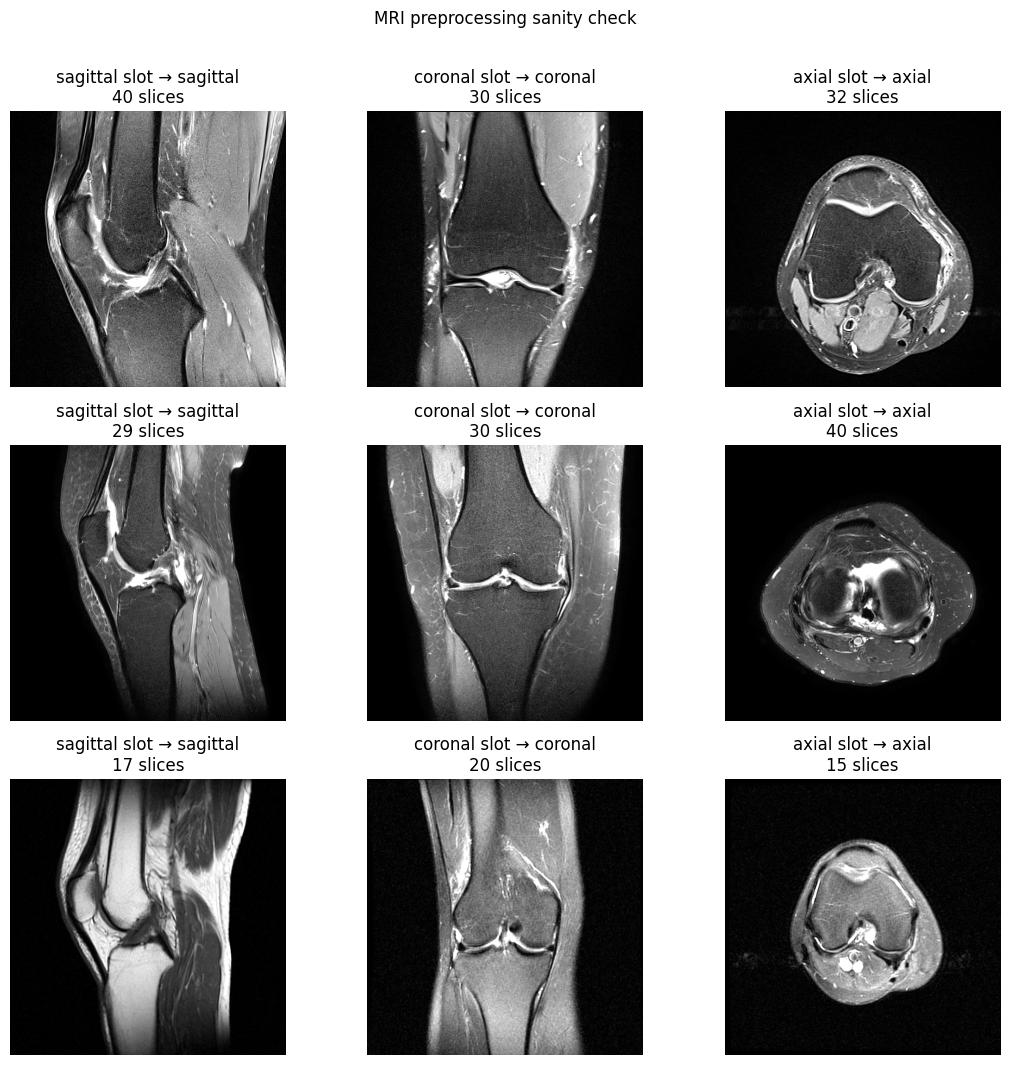

In [8]:
def select_plane_series(series_list):
    chosen = []
    used_dirs = set()
    for plane in PLANE_ORDER:
        candidates = [s for s in series_list if s['plane'] == plane]
        if candidates:
            best = max(candidates, key=lambda x: x['n_slices'])
            chosen.append(best)
            used_dirs.add(best['dir'])
        else:
            chosen.append(None)
    fallbacks = sorted([s for s in series_list if s['dir'] not in used_dirs], key=lambda x: x['n_slices'], reverse=True)
    for i in range(len(chosen)):
        if chosen[i] is None and fallbacks:
            chosen[i] = fallbacks.pop(0)
    return chosen


def read_dicom_array(path):
    ds = pydicom.dcmread(path, force=True)
    arr = ds.pixel_array.astype(np.float32)
    if arr.ndim > 2:
        arr = arr[arr.shape[0] // 2]
    slope = float(getattr(ds, 'RescaleSlope', 1.0))
    intercept = float(getattr(ds, 'RescaleIntercept', 0.0))
    arr = arr * slope + intercept
    if str(getattr(ds, 'PhotometricInterpretation', '')).upper() == 'MONOCHROME1':
        arr = arr.max() - arr
    lo, hi = np.percentile(arr, (1, 99))
    if hi <= lo:
        return np.zeros_like(arr, dtype=np.float32)
    arr = np.clip(arr, lo, hi)
    arr = (arr - lo) / (hi - lo)
    return arr.astype(np.float32)

available_train_uids = [u for u in train_df[SUBMISSION_ID].astype(str) if u in DICOM_INDEX]
rng = np.random.default_rng(SEED)
example_uids = rng.choice(available_train_uids, size=min(3, len(available_train_uids)), replace=False)

fig, axes = plt.subplots(len(example_uids), 3, figsize=(11, 3.5 * len(example_uids)))
axes = np.atleast_2d(axes)
for r, uid in enumerate(example_uids):
    selected = select_plane_series(DICOM_INDEX[uid])
    for c, (requested_plane, series) in enumerate(zip(PLANE_ORDER, selected)):
        ax = axes[r, c]
        if series is None:
            ax.axis('off')
            continue
        files = series['files']
        arr = read_dicom_array(files[len(files)//2])
        ax.imshow(arr, cmap='gray')
        ax.set_title(f'{requested_plane} slot → {series["plane"]}\n{series["n_slices"]} slices')
        ax.axis('off')
plt.suptitle('MRI preprocessing sanity check', y=1.01)
plt.tight_layout()
plt.show()

## 7. Dataset — plane-aware 2.5D triplets

Each selected MRI series contributes three nearby slices. The slices become pseudo-RGB channels and are resized with PyTorch, avoiding an OpenCV dependency. Random center jitter during training is a cheap augmentation over slice position.

In [9]:
def resize_2d(arr, size=IMG_SIZE):
    t = torch.from_numpy(arr).float()[None, None]
    t = F.interpolate(t, size=(size, size), mode='bilinear', align_corners=False)
    return t[0, 0]


def sample_triplet(files, train_mode=False):
    n = len(files)
    if n == 0:
        return torch.zeros(3, IMG_SIZE, IMG_SIZE)
    center = n // 2
    if train_mode and n >= 7:
        jitter = random.randint(-max(1, n // 10), max(1, n // 10))
        center = int(np.clip(center + jitter, 1, n - 2))
    delta = max(1, n // 12)
    idxs = [max(0, center - delta), center, min(n - 1, center + delta)]
    channels = []
    for idx in idxs:
        try:
            arr = read_dicom_array(files[idx])
            channels.append(resize_2d(arr))
        except Exception:
            channels.append(torch.zeros(IMG_SIZE, IMG_SIZE))
    x = torch.stack(channels, dim=0)
    if train_mode and random.random() < 0.5:
        x = torch.flip(x, dims=[2])
    return x


class KneeStudyDataset(Dataset):
    def __init__(self, frame, dicom_index, targets=None, train_mode=False):
        self.frame = frame.reset_index(drop=True)
        self.index = dicom_index
        self.targets = targets
        self.train_mode = train_mode

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        uid = str(row[SUBMISSION_ID])
        series = select_plane_series(self.index.get(uid, []))
        views, mask = [], []
        for s in series:
            if s is None:
                views.append(torch.zeros(3, IMG_SIZE, IMG_SIZE))
                mask.append(0.0)
            else:
                views.append(sample_triplet(s['files'], self.train_mode))
                mask.append(1.0)
        x = torch.stack(views, dim=0)  # [views, channels, H, W]
        view_mask = torch.tensor(mask, dtype=torch.float32)

        out = {'image': x, 'view_mask': view_mask, 'uid': uid}
        if self.targets is not None:
            y = pd.to_numeric(row[self.targets], errors='coerce').to_numpy(dtype=np.float32)
            out['target'] = torch.from_numpy(y)
        return out

## 8. Model — shared ResNet-18 + view attention

The encoder is intentionally small. The learned attention pool is cheap but allows the network to emphasize the most informative plane. No external weights are required, so this anchor remains fully offline and reproducible.

In [10]:
class PlaneAwareMIL(nn.Module):
    def __init__(self, n_targets, n_views=N_VIEWS):
        super().__init__()
        backbone = resnet18(weights=None)
        feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.encoder = backbone
        self.view_embedding = nn.Parameter(torch.zeros(1, n_views, feature_dim))
        nn.init.normal_(self.view_embedding, std=0.02)
        self.attention = nn.Sequential(
            nn.Linear(feature_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1),
        )
        self.head = nn.Sequential(
            nn.LayerNorm(feature_dim),
            nn.Dropout(0.20),
            nn.Linear(feature_dim, n_targets),
        )

    def forward(self, x, view_mask=None):
        b, v, c, h, w = x.shape
        feat = self.encoder(x.reshape(b * v, c, h, w)).reshape(b, v, -1)
        feat = feat + self.view_embedding[:, :v]
        attn_logits = self.attention(feat).squeeze(-1)
        if view_mask is not None:
            attn_logits = attn_logits.masked_fill(view_mask <= 0, -1e4)
        attn = torch.softmax(attn_logits, dim=1)
        pooled = torch.sum(feat * attn.unsqueeze(-1), dim=1)
        logits = self.head(pooled)
        return logits, attn

model = PlaneAwareMIL(len(TARGETS)).to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable/1e6:.2f}M')

Trainable parameters: 11.25M


## 9. Loss, metric, and loaders

Macro AUC is computed target-by-target and only on targets where validation contains both classes. Missing labels are masked rather than imputed. Positive-class weights are estimated only from the training split.

In [11]:
train_part = train_df.iloc[train_idx].reset_index(drop=True)
val_part = train_df.iloc[val_idx].reset_index(drop=True)
test_part = test_df.copy().reset_index(drop=True)
if MAX_TEST_STUDIES is not None:
    test_part = test_part.iloc[:MAX_TEST_STUDIES].copy()

train_ds = KneeStudyDataset(train_part, DICOM_INDEX, TARGETS, train_mode=True)
val_ds = KneeStudyDataset(val_part, DICOM_INDEX, TARGETS, train_mode=False)
test_ds = KneeStudyDataset(test_part, DICOM_INDEX, targets=None, train_mode=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                          pin_memory=True, persistent_workers=NUM_WORKERS > 0, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                        pin_memory=True, persistent_workers=NUM_WORKERS > 0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                         pin_memory=True, persistent_workers=NUM_WORKERS > 0)

train_y = train_part[TARGETS].apply(pd.to_numeric, errors='coerce').to_numpy(np.float32)
pos = np.nansum(train_y == 1, axis=0)
neg = np.nansum(train_y == 0, axis=0)
pos_weight = torch.tensor(np.divide(neg, np.maximum(pos, 1)), dtype=torch.float32, device=DEVICE)
print('Positive weights:')
display(pd.Series(pos_weight.detach().cpu().numpy(), index=TARGETS).round(2).to_frame('pos_weight'))


def masked_weighted_bce(logits, targets, pos_weight):
    mask = torch.isfinite(targets)
    safe_targets = torch.nan_to_num(targets, nan=0.0)
    loss = F.binary_cross_entropy_with_logits(logits, safe_targets, pos_weight=pos_weight, reduction='none')
    loss = loss * mask
    return loss.sum() / mask.sum().clamp_min(1)


def macro_auc(y_true, y_prob):
    aucs = {}
    for j, target in enumerate(TARGETS):
        mask = np.isfinite(y_true[:, j])
        yt = y_true[mask, j]
        yp = y_prob[mask, j]
        if len(np.unique(yt)) < 2:
            aucs[target] = np.nan
        else:
            aucs[target] = roc_auc_score(yt, yp)
    return float(np.nanmean(list(aucs.values()))), aucs

Positive weights:


,pos_weight
ACL,1.13
MCL,6.00
Medial Meniscus,1.13
Lateral Meniscus,1.33
Medial OA,2.50
Lateral OA,3.45
PF OA,1.72
Effusion,0.69
Synovitis,1.13
Baker's,3.08


## 10. GPU training

The best checkpoint is selected strictly by validation macro AUC. Raw epoch loss/AUC values are preserved in `history` and saved to CSV.

In [12]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler('cuda', enabled=AMP_ENABLED)

best_auc = -np.inf
best_state = None
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    seen = 0
    for batch in train_loader:
        x = batch['image'].to(DEVICE, non_blocking=True)
        view_mask = batch['view_mask'].to(DEVICE, non_blocking=True)
        y = batch['target'].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=AMP_ENABLED):
            logits, _ = model(x, view_mask)
            loss = masked_weighted_bce(logits, y, pos_weight)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = x.size(0)
        running_loss += loss.item() * bs
        seen += bs

    model.eval()
    val_probs, val_targets = [], []
    with torch.no_grad():
        for batch in val_loader:
            x = batch['image'].to(DEVICE, non_blocking=True)
            view_mask = batch['view_mask'].to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=AMP_ENABLED):
                logits, _ = model(x, view_mask)
            val_probs.append(torch.sigmoid(logits).float().cpu().numpy())
            val_targets.append(batch['target'].numpy())

    vp = np.concatenate(val_probs)
    vy = np.concatenate(val_targets)
    auc, per_target = macro_auc(vy, vp)
    epoch_loss = running_loss / max(seen, 1)
    history.append({'epoch': epoch, 'train_loss': epoch_loss, 'val_macro_auc': auc, **{f'auc_{k}': v for k, v in per_target.items()}})
    print(f'Epoch {epoch:02d}/{EPOCHS} | train loss {epoch_loss:.5f} | val macro AUC {auc:.5f}')

    if auc > best_auc:
        best_auc = auc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    scheduler.step()

history_df = pd.DataFrame(history)
history_df.to_csv('training_history.csv', index=False)
print(f'Best validation macro AUC: {best_auc:.6f}')

Epoch 01/4 | train loss 0.11464 | val macro AUC 0.48996
Epoch 02/4 | train loss 0.10258 | val macro AUC 0.50500
Epoch 03/4 | train loss 0.09655 | val macro AUC 0.48008
Epoch 04/4 | train loss 0.08734 | val macro AUC 0.49409
Best validation macro AUC: 0.505000


## 11. Validation diagnostics

Macro AUC can hide target failure. The per-target chart is therefore the primary diagnostic for deciding which pathology needs a plane-specific or localization-specific challenger.

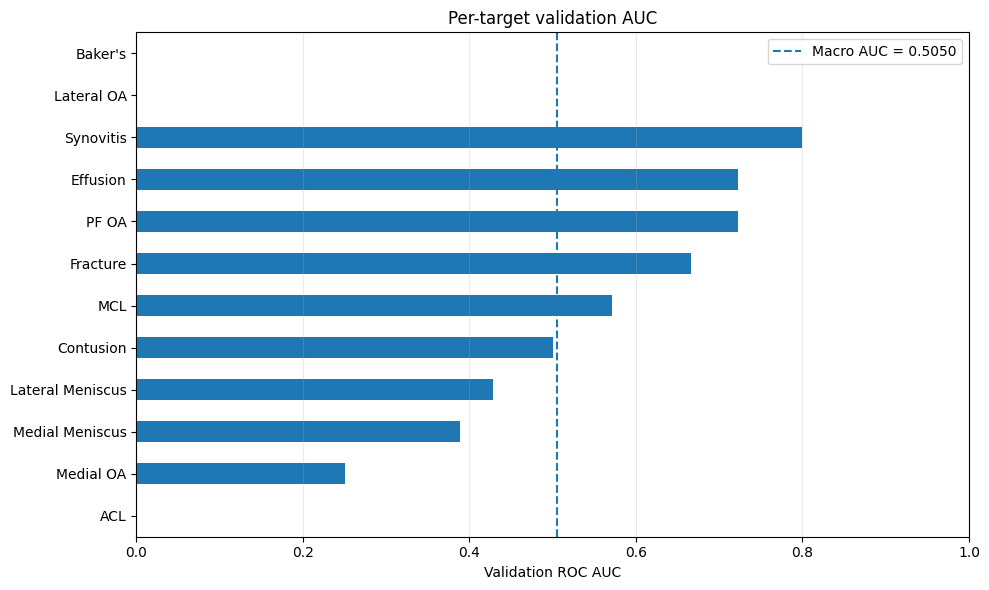

,validation_auc
ACL,0.00000
Medial OA,0.25000
Medial Meniscus,0.38889
Lateral Meniscus,0.42857
Contusion,0.50000
MCL,0.57143
Fracture,0.66667
PF OA,0.72222
Effusion,0.72222
Synovitis,0.80000


In [13]:
model.load_state_dict(best_state)
model.to(DEVICE).eval()

val_probs, val_targets, val_attn = [], [], []
with torch.no_grad():
    for batch in val_loader:
        x = batch['image'].to(DEVICE, non_blocking=True)
        view_mask = batch['view_mask'].to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=AMP_ENABLED):
            logits, attn = model(x, view_mask)
        val_probs.append(torch.sigmoid(logits).float().cpu().numpy())
        val_attn.append(attn.float().cpu().numpy())
        val_targets.append(batch['target'].numpy())

val_probs = np.concatenate(val_probs)
val_targets = np.concatenate(val_targets)
val_attn = np.concatenate(val_attn)
best_macro_auc, target_aucs = macro_auc(val_targets, val_probs)
auc_series = pd.Series(target_aucs).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
auc_series.plot(kind='barh', ax=ax)
ax.axvline(best_macro_auc, linestyle='--', label=f'Macro AUC = {best_macro_auc:.4f}')
ax.set_xlim(0, 1)
ax.set_xlabel('Validation ROC AUC')
ax.set_title('Per-target validation AUC')
ax.legend()
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

display(auc_series.to_frame('validation_auc').round(5))

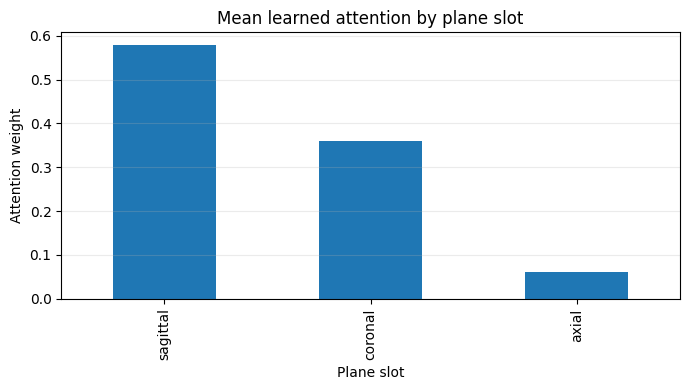

sagittal    0.5791
coronal     0.3589
axial       0.0619
dtype: float32


In [14]:
mean_attention = pd.Series(val_attn.mean(axis=0), index=PLANE_ORDER)
fig, ax = plt.subplots(figsize=(7, 4))
mean_attention.plot(kind='bar', ax=ax)
ax.set_title('Mean learned attention by plane slot')
ax.set_ylabel('Attention weight')
ax.set_xlabel('Plane slot')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()
print(mean_attention.round(4))

## 12. Test inference and `submission.csv`

No post-hoc clipping, smoothing, or blending is applied beyond the sigmoid mapping from logits to probabilities. The raw model ranking signal is preserved for the AUC metric.

In [15]:
test_probs = []
with torch.no_grad():
    for batch in test_loader:
        x = batch['image'].to(DEVICE, non_blocking=True)
        view_mask = batch['view_mask'].to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=AMP_ENABLED):
            logits, _ = model(x, view_mask)
        test_probs.append(torch.sigmoid(logits).float().cpu().numpy())

test_probs = np.concatenate(test_probs)

submission = sample_submission.copy()
pred_map = pd.DataFrame(test_probs, columns=TARGETS)
pred_map[SUBMISSION_ID] = test_part[SUBMISSION_ID].astype(str).values
submission[SUBMISSION_ID] = submission[SUBMISSION_ID].astype(str)
submission = submission[[SUBMISSION_ID]].merge(pred_map, on=SUBMISSION_ID, how='left')

if submission[TARGETS].isna().any().any():
    missing_rows = submission[TARGETS].isna().all(axis=1).sum()
    raise RuntimeError(f'Missing predictions for {missing_rows} submission rows. Check hidden-test DICOM indexing.')

submission.to_csv('submission.csv', index=False)
torch.save({
    'model_state_dict': best_state,
    'targets': TARGETS,
    'config': {
        'img_size': IMG_SIZE,
        'epochs': EPOCHS,
        'seed': SEED,
        'planes': PLANE_ORDER,
        'architecture': 'ResNet18 + plane attention MIL',
    },
    'validation_macro_auc': best_macro_auc,
    'validation_target_auc': target_aucs,
}, 'rsna_knee_2p5d_mil_baseline.pth')

print('submission.csv written:', submission.shape)
display(submission.head())

submission.csv written: (3, 13)


,StudyInstanceUID,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10047035057544427318...,0.762207,0.796875,0.486328,0.236328,0.227295,0.634766,0.436768,0.540527,0.305908,0.258057,0.593750,0.381348
1,1.2.826.0.1.3680043.8.498.10062861783145312629...,0.744141,0.689941,0.488525,0.262939,0.187744,0.562988,0.488281,0.598633,0.335449,0.186890,0.708984,0.379883
2,1.2.826.0.1.3680043.8.498.10067514707072572280...,0.766113,0.806641,0.477783,0.300537,0.232666,0.501465,0.409668,0.574707,0.329102,0.299561,0.615234,0.311768


## 13. Baseline verdict and next experiments

This notebook is the **MRI anchor**, not the endpoint. The next experiments should be evaluated one at a time against the same leakage-safe OOF protocol:

1. **Pretrained encoder challenger** — attach an offline ImageNet/medical/SSL checkpoint (ConvNeXt, EfficientNetV2, DINOv2/Swin) and quantify the OOF lift over random initialization.
2. **Target-specific plane experts** — ACL/menisci vs OA/cartilage vs effusion/synovitis/Baker's vs bone targets likely benefit from different plane weighting and slice coverage.
3. **Slice-localized MIL** — replace central-triplet sampling with 8–16 candidate slices per series and attention/top-k pooling; measure gain per target and runtime cost.
4. **Radiology report fusion** — only after establishing strict train/test availability and leakage rules for text. Use report embeddings as an explicit challenger, never as an unverified shortcut.
5. **Fold ensemble / distillation** — once architecture stabilizes, use diverse OOF folds and distill into an efficiency-track student if runtime becomes limiting.

**Failure criterion:** if the preprocessing montage is wrong, DICOM coverage is low, validation has single-class targets, or an improvement exists only on public LB without reproducible OOF gain, stop and diagnose before scaling.